## On-line Training for MDP and Mon-MDP

1 - from a saved replay buffer

2 - while building the replay buffer

In [1]:
import numpy as np
import time
import gymnasium as gym
import random
import torch
from collections import namedtuple, Counter
import matplotlib.pyplot as plt

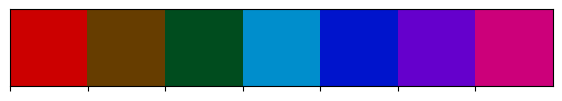

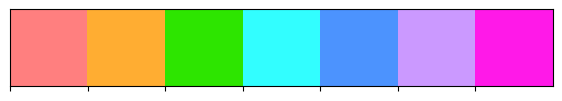

In [2]:
import os
import sys
SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.wrappers.env_wrappers import ChannelsObs, StochasticAction, TimeStepReward
from src.replay_buffer import TorchReplayMemory
from src.wrappers.monitor_wrappers import BinaryMonitor
from src.policy_analysis import ind_to_action

In [3]:
device = "mps:0"
env_random = 0.0
obs_size = (3, 9, 9)
gamma = 0.99
lr = 1e-4
tau = 0.005
max_timesteps = 5000
n_ep = 1000
batch_size = 128
loss_fun = torch.nn.MSELoss() # torch.nn.SmoothL1Loss()

In [4]:
Transition = namedtuple("Transition", ("obs", "action", "next_obs", "reward"))

def get_action_ind(mdp_action, mon_action, n_mdp_actions: int = 4) -> int:
    """convert a dictionary of MDP and Monitor actions to an index"""
    return mon_action * n_mdp_actions + mdp_action
    
def process_batch(batch, device: str):
    batch = Transition(*zip(*batch))
    real_reward_mask = [not np.isnan(p) for p in [r["mdp"] for r in batch.reward]]
    if len(real_reward_mask) == 0:
        raise ValueError("All nan")
    real_reward_idx = [i for i, x in enumerate(real_reward_mask) if x]
    non_final_mask = torch.tensor(tuple(map(lambda s: s["mdp"] is not None, batch.next_obs)), dtype=torch.bool)
    if device in ["cpu", None]:
        non_final_next_states = torch.tensor(
            np.array([s["mdp"] for s in batch.next_obs if s["mdp"] is not None]), dtype=torch.float,
        )
        mdp_obs = torch.tensor(np.array([state["mdp"] for state in batch.obs]), dtype=torch.float)
        mon_obs = torch.tensor(np.array([state["monitor"] for state in batch.obs]), dtype=torch.float)
        mdp_reward = torch.tensor(np.array([reward["mdp"] for reward in batch.reward]), dtype=torch.float)
        mon_reward = torch.tensor(np.array([reward["monitor"] for reward in batch.reward]), dtype=torch.float)
        mdp_action = torch.tensor(np.array([a["mdp"] for a in batch.action]))
        mon_action = torch.tensor(np.array([a["monitor"] for a in batch.action]))
    else:
        non_final_mask = torch.tensor(tuple(map(lambda s: s["mdp"] is not None, batch.next_obs)), dtype=torch.bool)
        non_final_next_states = torch.tensor(
            np.array([s["mdp"] for s in batch.next_obs if s["mdp"] is not None]), device=device, dtype=torch.float,
        )
        
        mdp_obs = torch.tensor(np.array([state["mdp"] for state in batch.obs]), device=device, dtype=torch.float)
        mon_obs = torch.tensor(np.array([state["monitor"] for state in batch.obs]), device=device, dtype=torch.float)
    
    
        mdp_reward = torch.tensor(np.array([reward["mdp"] for reward in batch.reward]), device=device, dtype=torch.float)
        mon_reward = torch.tensor(np.array([reward["monitor"] for reward in batch.reward]), device=device, dtype=torch.float)
    
        mdp_action = torch.tensor(np.array([a["mdp"] for a in batch.action]), device=device)
        mon_action = torch.tensor(np.array([a["monitor"] for a in batch.action]), device=device)
    
        # non_final_next_states = torch.stack([s["mdp"] for s in batch.next_obs if s["mdp"] is not None])
        # mdp_obs = torch.stack([state["mdp"] for state in batch.obs])
        # mon_obs = torch.stack([state["monitor"] for state in batch.obs])

        # mdp_reward = torch.stack([reward["mdp"] for reward in batch.reward])
        # mon_reward = torch.stack([reward["monitor"] for reward in batch.reward])

        # mdp_action = torch.stack([a["mdp"] for a in batch.action]).to(torch.int64)
        # mon_action = torch.stack([a["monitor"] for a in batch.action]).to(torch.int64)

    process_batch = {
        "real_reward_idx": real_reward_idx,
        "mdp_obs": mdp_obs,
        "mon_obs": mon_obs.unsqueeze(1),
        "non_final_mask": non_final_mask,
        "non_final_next_states": non_final_next_states,
        "mdp_reward": mdp_reward.unsqueeze(1),
        "mon_reward": mon_reward.unsqueeze(1),
        "mdp_action": mdp_action.unsqueeze(1),
        "mon_action": mon_action.unsqueeze(1),
    }
    return process_batch

def dqn_network(n_actions: int, device: str):
    return torch.nn.Sequential(
                torch.nn.Conv2d(obs_size[0], 8, 3),
                torch.nn.ReLU(),
                torch.nn.Conv2d(8, 4, 3),
                torch.nn.ReLU(),
                torch.nn.Flatten(),
                torch.nn.Linear(100, 64),
                torch.nn.ReLU(),
                torch.nn.Linear(64, n_actions),
    ).to(device)

def optimize_policy_model(
    policy_net, target_net, optimizer, loss_fun, mdp_obs, mdp_action, mdp_reward, non_final_next_states, non_final_mask,
):
    q_values = policy_net(mdp_obs).gather(1, mdp_action)
    next_q_values = torch.zeros(mdp_obs.shape[0], device=device)
    with torch.no_grad():
        next_q_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    expected_q_values = (gamma * next_q_values.unsqueeze(1)) + mdp_reward
    loss = loss_fun(q_values, expected_q_values)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

def optimize_mon_policy_model(
    policy_net, target_net, optimizer, loss_fun, mdp_obs, mdp_action, mon_action, mdp_reward, mon_reward, non_final_next_states, non_final_mask,
):
    combined_action = get_action_ind(mdp_action, mon_action)
    combined_reward = mdp_reward + mon_reward
    q_values = policy_net(mdp_obs).gather(1, combined_action)
    next_q_values = torch.zeros(mdp_obs.shape[0], device=device)
    with torch.no_grad():
        next_q_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    expected_q_values = (gamma * next_q_values.unsqueeze(1)) + combined_reward
    loss = loss_fun(q_values, expected_q_values)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

def update_target_network(policy_network, target_network, tau: float) -> None:
    if 0 > tau > 1:
        raise ValueError("tau should be between 0 and 1")
    target_net_state_dict = target_network.state_dict()
    policy_net_state_dict = policy_network.state_dict()
    for key in policy_net_state_dict:
        target_net_state_dict[key] = policy_net_state_dict[key] * tau + target_net_state_dict[key] * (1 - tau)
    target_network.load_state_dict(target_net_state_dict)

def select_action(q_values) -> int:
    indx = np.argwhere(q_values == np.max(q_values))
    return random.choice(indx)[0]

## MDP with a saved replay buffer

In [5]:
# mdp_buffer = np.load("../models/9_9/Penalty/q_learning/env_0.0/eps_1.0/q_lr_1.0/reward_lr_1.0/replay_buffer.npy", allow_pickle=True)[()]

In [10]:
env = gym.make("gym_monitor/TreasureHunt-Penalty-v1", render_modes="human", seed=0)
env = ChannelsObs(env, grid_size=(9,9), n_objects=3)
env = TimeStepReward(env, timestep_penalty=0.0, goal_reward=1, fire_reward=-10)
env = StochasticAction(env, random_prob=env_random)

In [7]:
policy_net = dqn_network(4, device)
target_net = dqn_network(4, device)
target_net.load_state_dict(policy_net.state_dict())
optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr)
mdp_buffer = TorchReplayMemory(int(1e6))

In [8]:
env = BinaryMonitor(env, full_monitor=True, monitor_cost=0.2, init_monitor_state=0.0, monitor_reset_prob=0.0)
current_eps = 1.0
dec_rate = 1e-5
min_eps = 0.0

q_loss = []
rewards = []
total_timesteps = 0
ep_reward = []

batch_timer = []
model_timer = []
infernce_timer = []
prepare_batch = []
zero_time = time.time()
for ep in range(500):
    s, _ = env.reset()
    R = 0
    ep_reward_loss = []
    for i in range(max_timesteps):
        if mdp_buffer.buffer_size > 5e4:
            start = time.time()
            samples = random.sample(list(mdp_buffer.memory), batch_size)
            batch = process_batch(samples, device)
            batch_timer.append(time.time() - start)

            start = time.time()
            ep_loss = optimize_policy_model(
                policy_net, target_net, optimizer, loss_fun, batch["mdp_obs"], batch["mdp_action"], batch["mdp_reward"], batch["non_final_next_states"], batch["non_final_mask"],
            )
    
            q_loss.append(ep_loss)
    
            update_target_network(policy_net, target_net, tau)
            model_timer.append(time.time() - start)

        if np.random.random() < current_eps:
            start = time.time()
            with torch.no_grad():
                q_value = np.squeeze(policy_net(torch.tensor(s["mdp"], dtype=torch.float32, device=device).unsqueeze(0)).detach().cpu().numpy())
            action = {"mdp": select_action(q_value), "monitor": 1}
            infernce_timer.append(time.time() - start)
            
        else:
            action = env.action_space.sample()

        next_s, r, done, _, info = env.step(action)
        start = time.time()
        mdp_buffer.push(s, action, {"mdp": None, "monitor": None} if done else next_s, r)
        # if device in ["cpu", None]:
        #     mdp_buffer.push(s, action, {"mdp": None, "monitor": None} if done else next_s, r)
        # else:
        #     mdp_buffer.push(
        #         {"mdp": torch.tensor(s["mdp"], dtype=torch.float, device=device), "monitor": torch.tensor(s["monitor"], dtype=torch.float, device=device)},
        #         {"mdp": torch.tensor(action["mdp"], dtype=torch.float, device=device), "monitor": torch.tensor(action["monitor"], dtype=torch.float, device=device)},
        #         {"mdp": None, "monitor": None} if done else {"mdp": torch.tensor(next_s["mdp"], dtype=torch.float, device=device), "monitor": torch.tensor(next_s["monitor"], dtype=torch.float, device=device)},
        #         {"mdp": torch.tensor(r["mdp"], dtype=torch.float, device=device), "monitor": torch.tensor(r["monitor"], dtype=torch.float, device=device)},
        #     )
        prepare_batch.append(time.time() - start)
        rewards.append(r["mdp"])
        # new_env.render("human")
        R += r["mdp"] * (gamma ** i)
        current_eps = max(min_eps, current_eps - dec_rate)
        if done:
            break
        s = next_s
    total_timesteps += i
    if ep % 25 == 0:
        print("episode", ep + 1, "reward", R, "timesteps", i + 1, "current eps", current_eps, "total timesteps", total_timesteps)
        if len(q_loss) > 0:
            print("Q-loss {:.4f}".format(np.mean(q_loss)))
    ep_reward.append(R)
print("total timesteps", total_timesteps, "time", time.time() - zero_time)
env.close()

episode 1 reward 0.0 timesteps 5000 current eps 0.9500000000002276 total timesteps 4999
episode 26 reward -33.7390692371344 timesteps 604 current eps 0.24284000000201833 total timesteps 75690
Q-loss 0.0655
episode 51 reward -153.1666547733461 timesteps 151 current eps 0.08358000000191654 total timesteps 91591
Q-loss 0.0709
episode 76 reward -81.06688604853065 timesteps 335 current eps 0.0011900000019162485 total timesteps 99805
Q-loss 0.0916
episode 101 reward -127.3757199719897 timesteps 153 current eps 0.0 total timesteps 109887
Q-loss 0.1252
episode 126 reward -77.51764800498145 timesteps 379 current eps 0.0 total timesteps 121990
Q-loss 0.3007
episode 151 reward -74.51498316523774 timesteps 142 current eps 0.0 total timesteps 136552
Q-loss 0.7080
episode 176 reward -60.13969628304197 timesteps 254 current eps 0.0 total timesteps 146309
Q-loss 0.7017
episode 201 reward -61.205229039188495 timesteps 1480 current eps 0.0 total timesteps 157550
Q-loss 0.6431
episode 226 reward -52.7172

KeyboardInterrupt: 

In [19]:
398330 * 9 / 1000, 3085/60

(3584.97, 51.416666666666664)

In [9]:
print("prepare batch {:.5f} +- {:.3f} ms".format(1e3 * np.mean(prepare_batch), 1e3 * np.std(prepare_batch)))
print("batch processing time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(batch_timer), 1e3 * np.std(batch_timer)))
print("model time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(model_timer), 1e3 * np.std(model_timer)))
print("inference time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(infernce_timer), 1e3 * np.std(infernce_timer)))

prepare batch 0.00120 +- 0.001 ms
batch processing time 5.23395 +- 830.124 ms
model time 3.84218 +- 0.874 ms
inference time 0.59812 +- 0.553 ms


In [9]:
current_eps, total_timesteps

(0.0, 398330)

In [35]:
point = 10
print(batch["mdp_obs"][point][0])
policy_net(batch["mdp_obs"][point].unsqueeze(0))

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='mps:0')


tensor([[ 1.5584, -8.3655,  1.6336, -8.4140]], device='mps:0',
       grad_fn=<LinearBackward0>)

## Timer for CPU Network & replay buffer

In [ ]:
print("batch processing time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(batch_timer), 1e3 * np.std(batch_timer)))
print("model time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(model_timer), 1e3 * np.std(model_timer)))
print("inference time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(infernce_timer), 1e3 * np.std(infernce_timer)))

### Timer with GPU replay buffer batch size=124

In [9]:
print("batch processing time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(batch_timer), 1e3 * np.std(batch_timer)))
print("model time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(model_timer), 1e3 * np.std(model_timer)))
print("inference time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(infernce_timer), 1e3 * np.std(infernce_timer)))

batch processing time 24.50154 +- 1.081 ms
model time 6.11787 +- 0.918 ms
inference time 0.67618 +- 0.157 ms


### Timer for batch size = 512

In [8]:
print("batch processing time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(batch_timer), 1e3 * np.std(batch_timer)))
print("model time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(model_timer), 1e3 * np.std(model_timer)))
print("inference time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(infernce_timer), 1e3 * np.std(infernce_timer)))

batch processing time 15.08190 +- 0.421 ms
model time 3.66466 +- 0.797 ms
inference time 0.92521 +- 0.137 ms


### Timer for batch size = 256

In [22]:
print("batch processing time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(batch_timer), 1e3 * np.std(batch_timer)))
print("model time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(model_timer), 1e3 * np.std(model_timer)))
print("inference time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(infernce_timer), 1e3 * np.std(infernce_timer)))

batch processing time 8.62047 +- 0.434 ms
model time 3.71356 +- 0.389 ms
inference time 0.92490 +- 0.134 ms


In [4]:
# policy_net = torch.load("../models/9_9/Penalty/q_learning/env_0.0/eps_1.0/q_lr_1.0/reward_lr_1.0/mdp_q_policy")

In [22]:
# log_dir = "../models/9_9/Penalty/q_learning/env_0.0/eps_1.0/q_lr_0.001/reward_lr_0.001/online_full/"
# np.save(log_dir + "/q_loss_2", q_loss)
# np.save(log_dir + "/rewards_2", rewards)
# np.save(log_dir + "/ep_reward_2", ep_reward)
# torch.save(policy_net, log_dir + "policy_network_2")

In [22]:
s, _ = env.reset()
total_r = 0
for i in range(50):
    # print(s[0])
    with torch.no_grad():
        q_values = policy_net(torch.tensor(s["mdp"], dtype=torch.float32, device=device).unsqueeze(0))
    action = q_values.max(1).indices.view(1, 1).item()
    # print(action, "\n")
    s, r, done, _, info = env.step({"mdp": action, "monitor": 1})
    total_r += r["mdp"] * (gamma ** i)
    if done:
        break
print("timesteps", i, "reward", total_r)

timesteps 23 reward 0.7936142836436554


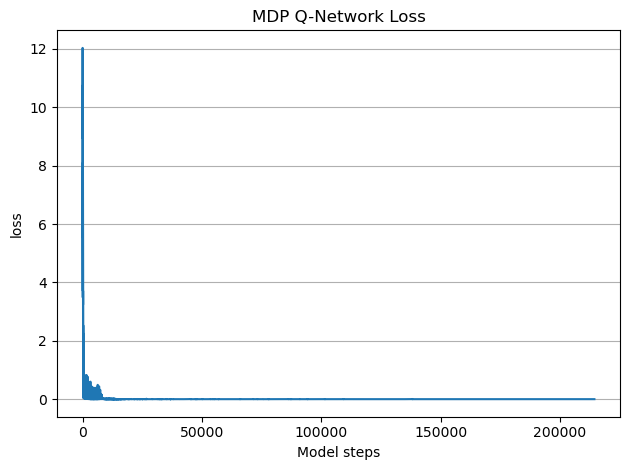

In [11]:
plt.plot(q_loss)
plt.xlabel("Model steps")
plt.ylabel("loss")
plt.grid(axis="y")
plt.title("MDP Q-Network Loss")
plt.tight_layout()

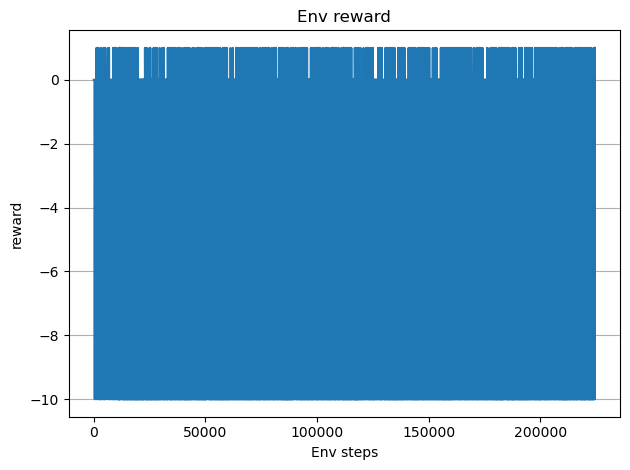

In [12]:
plt.plot(rewards)
plt.xlabel("Env steps")
plt.ylabel("reward")
plt.grid(axis="y")
plt.title("Env reward")
plt.tight_layout()

In [21]:
np.max(rewards)

1.0

In [13]:
inter = 250
mean_rewards = []
for i in range(0, len(rewards), inter):
    mean_rewards.append(np.mean(rewards[i: i + inter]))

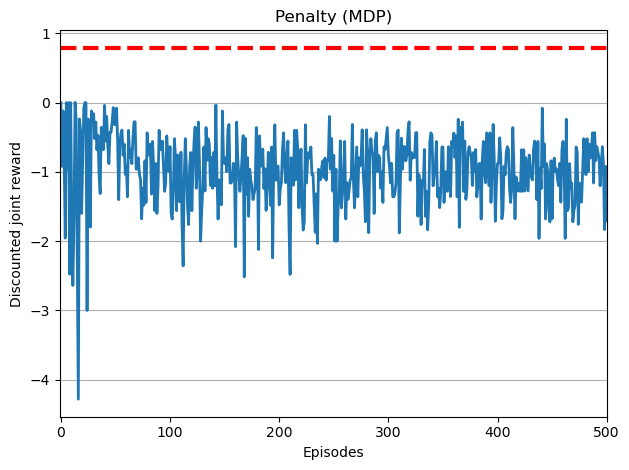

In [15]:
# plt.plot(ep_reward, lw=2)
plt.plot(mean_rewards, lw=2)
plt.hlines(0.79, 0, 500, color="r", lw=3, linestyle="--")
plt.xlabel("Episodes")
plt.ylabel("Discounted joint reward")
plt.grid(axis="y")
plt.title("Penalty (MDP)")
plt.xlim(-1, 500)
# plt.ylim(-10, 1)
plt.tight_layout()
# plt.savefig(log_dir + "/episode_reward", dpi=300)

## MDP with fully online

In [ ]:
# mon_buffer = np.load("../models/9_9/Penalty/reward_model/env_0.0/eps_1.0/q_lr_1.0/reward_lr_1.0/replay_buffer.npy", allow_pickle=True)[()]

## Mon-MDP with a saved replay buffer

## Mon-MDP fully online

In [11]:
policy_net = dqn_network(8, device)
target_net = dqn_network(8, device)
target_net.load_state_dict(policy_net.state_dict())
optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr)

reward_net = dqn_network(4, device)
reward_optimizer = torch.optim.Adam(reward_net.parameters(), lr=lr)
mon_buffer = TorchReplayMemory(int(1e6))

In [12]:
env = BinaryMonitor(env, full_monitor=False, monitor_cost=0.2, init_monitor_state=0.0, monitor_reset_prob=0.0)
q_loss = []
reward_loss = []
rewards = []
total_timesteps = 0
ep_reward = []

batch_timer = []
q_model_timer = []
r_model_timer = []
infernce_timer = []

current_eps = 1.0
dec_rate = 1e-5
min_eps = 0.0

zero_time = time.time()
real_reward_idx = []
for ep in range(n_ep):
    s, _ = env.reset()
    R = 0
    ep_reward_loss = []
    for i in range(max_timesteps):
        if mon_buffer.buffer_size > 1e4:
            start = time.time()
            while len(real_reward_idx) == 0:
                samples = random.sample(list(mon_buffer.memory), batch_size)
                batch = process_batch(samples, device)
                real_reward_idx = batch["real_reward_idx"]
            batch_timer.append(time.time() - start)

            
            with torch.no_grad():
                mdp_rewards = reward_net(batch["mdp_obs"]).gather(1, batch["mdp_action"])
            start = time.time()
            ep_loss = optimize_mon_policy_model(
                policy_net, target_net, optimizer, loss_fun, batch["mdp_obs"], batch["mdp_action"], batch["mon_action"], mdp_rewards, batch["mon_reward"], batch["non_final_next_states"], batch["non_final_mask"],
            )
    
            q_loss.append(ep_loss)
    
            update_target_network(policy_net, target_net, tau)
            q_model_timer.append(time.time() - start)

            # train reward model
            start = time.time()
            expected_reward = reward_net(batch["mdp_obs"][real_reward_idx]).gather(1, batch["mdp_action"][real_reward_idx])
            loss = loss_fun(batch["mdp_reward"][real_reward_idx], expected_reward)
        
            reward_optimizer.zero_grad()
            loss.backward()
            reward_optimizer.step()
            reward_loss.append(loss.item())
            r_model_timer.append(time.time() - start)

        if np.random.random() < current_eps:
            start = time.time()
            with torch.no_grad():
                q_value = policy_net(torch.tensor(s["mdp"], dtype=torch.float32, device=device).unsqueeze(0)).detach().cpu().numpy()
                mdp_a, mon_a = ind_to_action(select_action(q_value[0]), n_mdp_actions=4)
                action = {"mdp": mdp_a, "monitor": mon_a}
            infernce_timer.append(time.time() - start)

        else:
            action = env.action_space.sample()
        
        next_s, r, done, _, info = env.step(action)
        # mon_buffer.push(
        #     {"mdp": torch.tensor(s["mdp"], dtype=torch.float, device=device), "monitor": torch.tensor(s["monitor"], dtype=torch.float, device=device)},
        #     {"mdp": torch.tensor(action["mdp"], dtype=torch.float, device=device), "monitor": torch.tensor(action["monitor"], dtype=torch.float, device=device)},
        #     {"mdp": None, "monitor": None} if done else {"mdp": torch.tensor(next_s["mdp"], dtype=torch.float, device=device), "monitor": torch.tensor(next_s["monitor"], dtype=torch.float, device=device)},
        #     {"mdp": torch.tensor(r["mdp"], dtype=torch.float, device=device), "monitor": torch.tensor(r["monitor"], dtype=torch.float, device=device)},
        # )
        mon_buffer.push(s, action, {"mdp": None, "monitor": None} if done else next_s, r)
        rewards.append(r["mdp"])
        current_eps = max(min_eps, current_eps - dec_rate)
        # new_env.render("human")
        R += (info["mdp_reward"] + r["monitor"]) * (gamma ** i)
        if done:
            break
        s = next_s
    total_timesteps += i
    if ep % 25 == 0:
        print("episode", ep, "reward", R, "episode lenght", i + 1, "Total timesteps:", total_timesteps, "current eps", current_eps)
        if len(q_loss) > 0:
            print("Q-loss {:.2f}".format(np.mean(q_loss)))
        if len(reward_loss) > 0:
            print("Reward loss {:.2f}".format(np.mean(reward_loss)))
    ep_reward.append(R)
print("total timesteps", total_timesteps, "time", time.time() - zero_time)
env.close()

episode 0 reward -19.999732520490532 episode lenght 5000 Total timesteps: 4999 current eps 0.9500000000002276
episode 25 reward -8.966658375153479 episode lenght 9 Total timesteps: 12785 current eps 0.871890000000583
Q-loss 0.00
Reward loss 0.00
episode 50 reward -8.77092465209301 episode lenght 8 Total timesteps: 14641 current eps 0.8530800000006686
Q-loss 0.00
Reward loss 0.00
episode 75 reward -10.256609228706479 episode lenght 146 Total timesteps: 15176 current eps 0.8474800000006941
Q-loss 0.00
Reward loss 0.00
episode 100 reward -11.605963953073095 episode lenght 292 Total timesteps: 17130 current eps 0.8276900000007842
Q-loss 0.00
Reward loss 0.00
episode 125 reward -8.77092465209301 episode lenght 8 Total timesteps: 17399 current eps 0.8247500000007976
Q-loss 0.00
Reward loss 0.00
episode 150 reward -9.180601261496356 episode lenght 10 Total timesteps: 19571 current eps 0.8027800000008976
Q-loss 0.00
Reward loss 0.00
episode 175 reward -11.319346066783957 episode lenght 908 Tot

In [13]:
print("batch processing time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(batch_timer), 1e3 * np.std(batch_timer)))
print("Q-model time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(q_model_timer), 1e3 * np.std(q_model_timer)))
print("R-model time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(r_model_timer), 1e3 * np.std(r_model_timer)))
print("inference time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(infernce_timer), 1e3 * np.std(infernce_timer)))

batch processing time 0.00025 +- 0.005 ms
Q-model time 3.47052 +- 0.682 ms
R-model time 3.24069 +- 0.354 ms
inference time 0.64564 +- 0.379 ms


In [8]:
print("batch processing time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(batch_timer), 1e3 * np.std(batch_timer)))
print("Q-model time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(q_model_timer), 1e3 * np.std(q_model_timer)))
print("R-model time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(r_model_timer), 1e3 * np.std(r_model_timer)))
print("inference time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(infernce_timer), 1e3 * np.std(infernce_timer)))

batch processing time 2.25068 +- 0.525 ms
Q-model time 3.69674 +- 5.564 ms
R-model time 3.92466 +- 8.939 ms
inference time 0.76326 +- 3.411 ms


## Full CPU with Model & replay buffer

In [12]:
print("batch processing time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(batch_timer), 1e3 * np.std(batch_timer)))
print("Q-model time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(q_model_timer), 1e3 * np.std(q_model_timer)))
print("R-model time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(r_model_timer), 1e3 * np.std(r_model_timer)))
print("inference time {:.5f} +- {:.3f} ms".format(1e3 * np.mean(infernce_timer), 1e3 * np.std(infernce_timer)))

batch processing time 3.31801 +- 0.295 ms
Q-model time 17.33887 +- 1.529 ms
R-model time 1.55051 +- 1.786 ms
inference time 0.16859 +- 0.021 ms


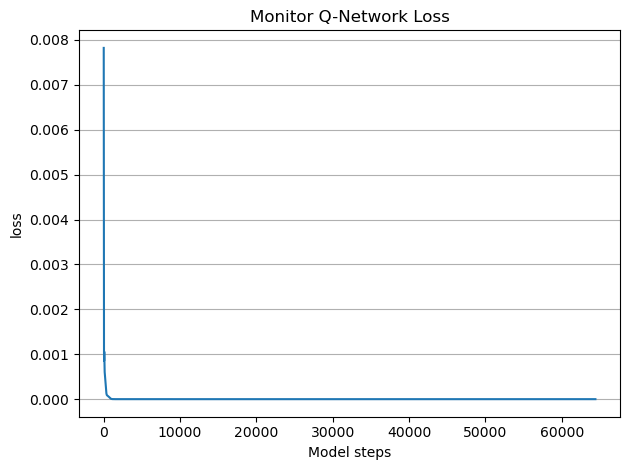

In [11]:
plt.plot(q_loss)
plt.xlabel("Model steps")
plt.ylabel("loss")
plt.grid(axis="y")
plt.title("Monitor Q-Network Loss")
plt.tight_layout()

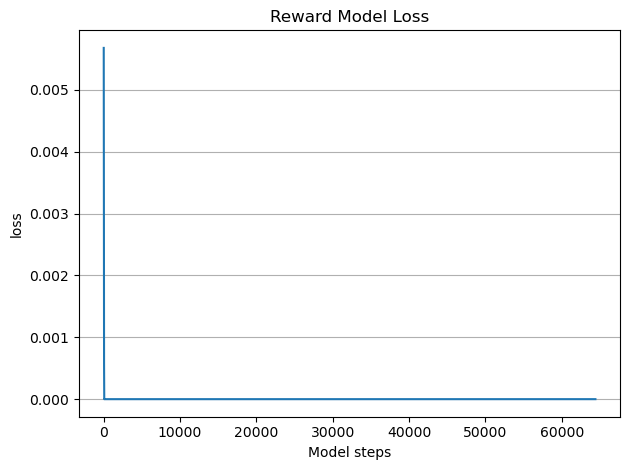

In [12]:
plt.plot(reward_loss)
plt.xlabel("Model steps")
plt.ylabel("loss")
plt.grid(axis="y")
plt.title("Reward Model Loss")
plt.tight_layout()

In [90]:
log_dir = "../models/9_9/Penalty/reward_model/env_0.0/eps_1.0/q_lr_0.001/reward_lr_0.001/online_full/"
np.save(log_dir + "/q_loss_0", q_loss)
# np.save(log_dir + "/rewards_0", rewards)
np.save(log_dir + "/ep_reward_0", ep_reward)
torch.save(policy_net, log_dir + "policy_network_0")

In [14]:
s, _ = env.reset()
for k in range(300):
    # print(s[0])
    with torch.no_grad():
        q_values = policy_net(torch.tensor(s["mdp"], dtype=torch.float32, device=device).unsqueeze(0))
    mdp_a, mon_a = ind_to_action(q_values.max(1).indices.view(1, 1).item(), n_mdp_actions=4)
    s, r, done, _, info = env.step({"mdp": mdp_a, "monitor": mon_a})
    if done:
        break
# print(s["mdp"][0])
print(k)

7


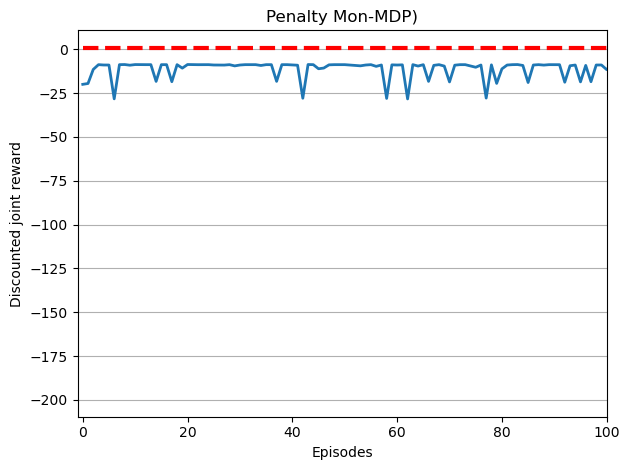

In [15]:
plt.plot(ep_reward, lw=2)
plt.hlines(0.79, 0, 100, color="r", lw=3, linestyle="--")
plt.xlabel("Episodes")
plt.ylabel("Discounted joint reward")
plt.grid(axis="y")
plt.title("Penalty Mon-MDP)")
plt.xlim(-1, 100)
# plt.ylim(-5, 1)
plt.tight_layout()
# plt.savefig(log_dir + "/episode_reward", dpi=300)

In [87]:
s["mdp"][0]

array([[0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [88]:
q_values

tensor([[0.9765, 0.9874, 0.9890, 1.0021, 0.7782, 0.7892, 0.7831, 0.7960]],
       device='mps:0')

In [22]:
indx_non = np.where(batch["mdp_reward"][real_reward_idx].cpu().numpy() > 0)[0]
indx_non

array([], dtype=int64)

In [33]:
point = 90
real_reward_idx = batch["real_reward_idx"]
print(batch["mdp_obs"][real_reward_idx][point][0])
print("reward", reward_net(batch["mdp_obs"][real_reward_idx][point].unsqueeze(0)))
policy_net(batch["mdp_obs"][real_reward_idx][point].unsqueeze(0))

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0.]], device='mps:0')
reward tensor([[-2.0638e-06,  8.0373e-02,  7.6571e-02, -1.1474e-06]], device='mps:0',
       grad_fn=<LinearBackward0>)


tensor([[ 0.0422, -0.1098,  0.0868,  0.0809, -0.1140, -0.1125, -0.0289, -0.1140]],
       device='mps:0', grad_fn=<LinearBackward0>)

In [32]:
batch["mdp_action"].shape

torch.Size([512, 1])